<a href="https://colab.research.google.com/github/toobaidrees/Tooba_Idrees_Data_Analytics/blob/main/Phase%202%20task%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Task 2: Customer Segmentation Using Unsupervised Learning

**Objective:** Cluster mall customers based on spending habits and propose tailored marketing strategies.

**Dataset:** Mall Customers Dataset (200 records)

**Pipeline:**
1. 📊 Exploratory Data Analysis (EDA)
2. 📈 Elbow & Silhouette Method (find optimal k)
3. 🎯 K-Means Clustering
4. 🗺️ PCA & t-SNE Visualization
5. 💡 Segment Profiles & Marketing Strategies

## 📦 Cell 1 – Install & Import Libraries

In [1]:
# All libraries below come pre-installed in Colab — no pip needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# ── Global style constants ────────────────────────────────────────────────
PALETTE  = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#A29BFE', '#6C5CE7']
LIGHT_BG = '#F8F9FA'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 📂 Cell 2 – Load Dataset

> **Option A** – load directly from Kaggle URL (recommended for Colab)  
> **Option B** – upload your own CSV file

In [2]:
# ── Option A: Load from Kaggle (recommended) ─────────────────────────────
# If you have a Kaggle account, run the lines below to download directly:
# !pip install kaggle -q
# from google.colab import files
# files.upload()   # upload your kaggle.json API token
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python --unzip
# df = pd.read_csv('Mall_Customers.csv')

# ── Option B: Upload your own CSV manually ────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick Mall_Customers.csv from your computer
# df = pd.read_csv(list(uploaded.keys())[0])

# ── Option C (DEFAULT): Inline dataset — works with zero setup ───────────
import io
DATA = """CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
1,Male,19,15,39\n2,Male,21,15,81\n3,Female,20,16,6\n4,Female,23,16,77
5,Female,31,17,40\n6,Female,22,17,76\n7,Female,35,18,6\n8,Female,23,18,94
9,Male,64,19,3\n10,Female,30,19,72\n11,Male,67,19,14\n12,Female,35,19,99
13,Female,58,20,15\n14,Female,24,20,77\n15,Male,37,20,13\n16,Male,22,20,79
17,Female,35,21,35\n18,Male,20,21,66\n19,Male,52,23,29\n20,Female,35,23,98
21,Male,35,24,35\n22,Male,25,24,73\n23,Female,46,25,5\n24,Male,31,25,73
25,Female,54,28,14\n26,Male,29,28,82\n27,Female,45,28,32\n28,Male,35,28,61
29,Female,40,29,31\n30,Female,23,29,87\n31,Male,60,30,4\n32,Female,21,30,73
33,Male,53,33,4\n34,Male,18,33,92\n35,Female,49,33,14\n36,Female,21,33,81
37,Female,42,34,17\n38,Female,30,34,73\n39,Male,36,37,26\n40,Female,20,37,75
41,Male,65,38,35\n42,Male,24,38,92\n43,Female,48,39,36\n44,Female,31,39,61
45,Female,49,39,28\n46,Female,24,39,65\n47,Female,50,40,55\n48,Female,27,40,47
49,Female,29,40,42\n50,Male,31,40,42\n51,Male,49,42,52\n52,Female,33,42,60
53,Female,31,43,54\n54,Male,59,43,60\n55,Female,50,43,45\n56,Male,47,43,41
57,Female,51,44,50\n58,Female,69,44,46\n59,Female,27,46,51\n60,Male,53,46,46
61,Male,70,46,56\n62,Female,19,46,55\n63,Female,67,47,52\n64,Female,54,47,59
65,Male,63,48,51\n66,Male,18,48,59\n67,Female,43,48,50\n68,Female,68,48,48
69,Male,19,48,59\n70,Female,32,48,47\n71,Male,70,49,55\n72,Female,47,49,42
73,Female,60,50,49\n74,Female,60,50,56\n75,Male,59,54,47\n76,Male,26,54,54
77,Female,45,54,53\n78,Male,40,54,48\n79,Female,23,54,52\n80,Female,49,54,42
81,Male,57,54,51\n82,Male,38,54,55\n83,Female,67,54,41\n84,Female,46,54,44
85,Male,21,54,57\n86,Male,48,54,46\n87,Female,55,57,58\n88,Female,22,57,55
89,Female,34,58,60\n90,Male,50,58,46\n91,Male,68,59,55\n92,Female,18,59,41
93,Male,48,60,49\n94,Female,40,60,40\n95,Female,32,60,42\n96,Female,24,60,52
97,Female,47,60,47\n98,Female,27,60,50\n99,Male,48,61,42\n100,Male,20,61,49
101,Female,23,62,41\n102,Female,49,62,48\n103,Female,67,62,59\n104,Female,26,62,55
105,Female,49,62,56\n106,Female,21,62,42\n107,Male,66,63,50\n108,Male,54,63,46
109,Female,68,63,43\n110,Male,66,63,48\n111,Male,65,63,52\n112,Female,19,63,54
113,Female,38,64,42\n114,Female,19,64,46\n115,Male,18,65,48\n116,Female,19,65,50
117,Female,63,65,43\n118,Female,49,65,59\n119,Female,51,67,43\n120,Male,50,67,57
121,Male,27,67,56\n122,Female,38,67,40\n123,Female,40,69,58\n124,Male,39,69,91
125,Male,23,70,29\n126,Female,31,70,77\n127,Female,43,71,35\n128,Male,40,71,95
129,Female,59,71,11\n130,Male,38,71,75\n131,Female,47,71,9\n132,Male,39,71,75
133,Male,25,72,34\n134,Female,31,72,71\n135,Female,20,73,5\n136,Male,29,73,88
137,Female,44,73,7\n138,Male,32,73,73\n139,Male,19,74,10\n140,Male,35,74,72
141,Female,57,75,5\n142,Male,32,75,93\n143,Female,28,76,40\n144,Male,32,76,87
145,Male,25,77,12\n146,Male,28,77,97\n147,Female,48,77,13\n148,Female,32,77,74
149,Female,34,78,10\n150,Female,34,78,72\n151,Female,43,78,12\n152,Female,39,78,60
153,Male,44,78,6\n154,Female,38,78,56\n155,Female,47,78,10\n156,Female,27,78,60
157,Female,37,78,4\n158,Female,30,78,56\n159,Female,34,79,77\n160,Female,30,79,72
161,Male,56,80,15\n162,Male,29,80,10\n163,Female,30,80,65\n164,Female,25,81,48
165,Male,21,81,41\n166,Female,36,82,56\n167,Male,30,82,35\n168,Female,30,82,65
169,Female,31,82,80\n170,Male,38,82,90\n171,Female,26,82,2\n172,Female,26,82,64
173,Male,29,83,72\n174,Female,30,83,60\n175,Female,40,83,55\n176,Female,37,83,65
177,Female,40,84,12\n178,Female,34,84,56\n179,Female,38,84,68\n180,Female,30,84,78
181,Female,31,85,22\n182,Female,32,85,64\n183,Female,38,85,14\n184,Female,35,85,60
185,Female,38,85,46\n186,Male,33,86,32\n187,Female,25,86,60\n188,Male,32,86,84
189,Male,34,87,25\n190,Male,24,87,79\n191,Female,36,87,20\n192,Female,27,87,86
193,Male,37,87,20\n194,Female,22,87,83\n195,Female,38,88,12\n196,Male,33,88,40
197,Male,27,88,20\n198,Female,24,88,55\n199,Female,38,88,12\n200,Female,35,89,14"""

df = pd.read_csv(io.StringIO(DATA))

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 🔍 Cell 3 – Basic Data Inspection

In [3]:
print('── Data Types ──────────────────────────')
print(df.dtypes)

print('\n── Statistical Summary ─────────────────')
display(df.describe().round(2))

print('\n── Missing Values ──────────────────────')
print(df.isnull().sum())

print('\n── Gender Counts ───────────────────────')
print(df['Gender'].value_counts())

── Data Types ──────────────────────────
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

── Statistical Summary ─────────────────


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,37.84,57.88,48.94
std,57.88,13.91,21.73,23.91
min,1.00,18.00,15.00,2.00
25%,50.75,27.00,41.50,35.00
50%,100.50,35.00,61.50,50.00
75%,150.25,48.00,78.00,64.00
max,200.00,70.00,89.00,99.00



── Missing Values ──────────────────────
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

── Gender Counts ───────────────────────
Gender
Female    124
Male       76
Name: count, dtype: int64


## 📊 Cell 4 – EDA Dashboard

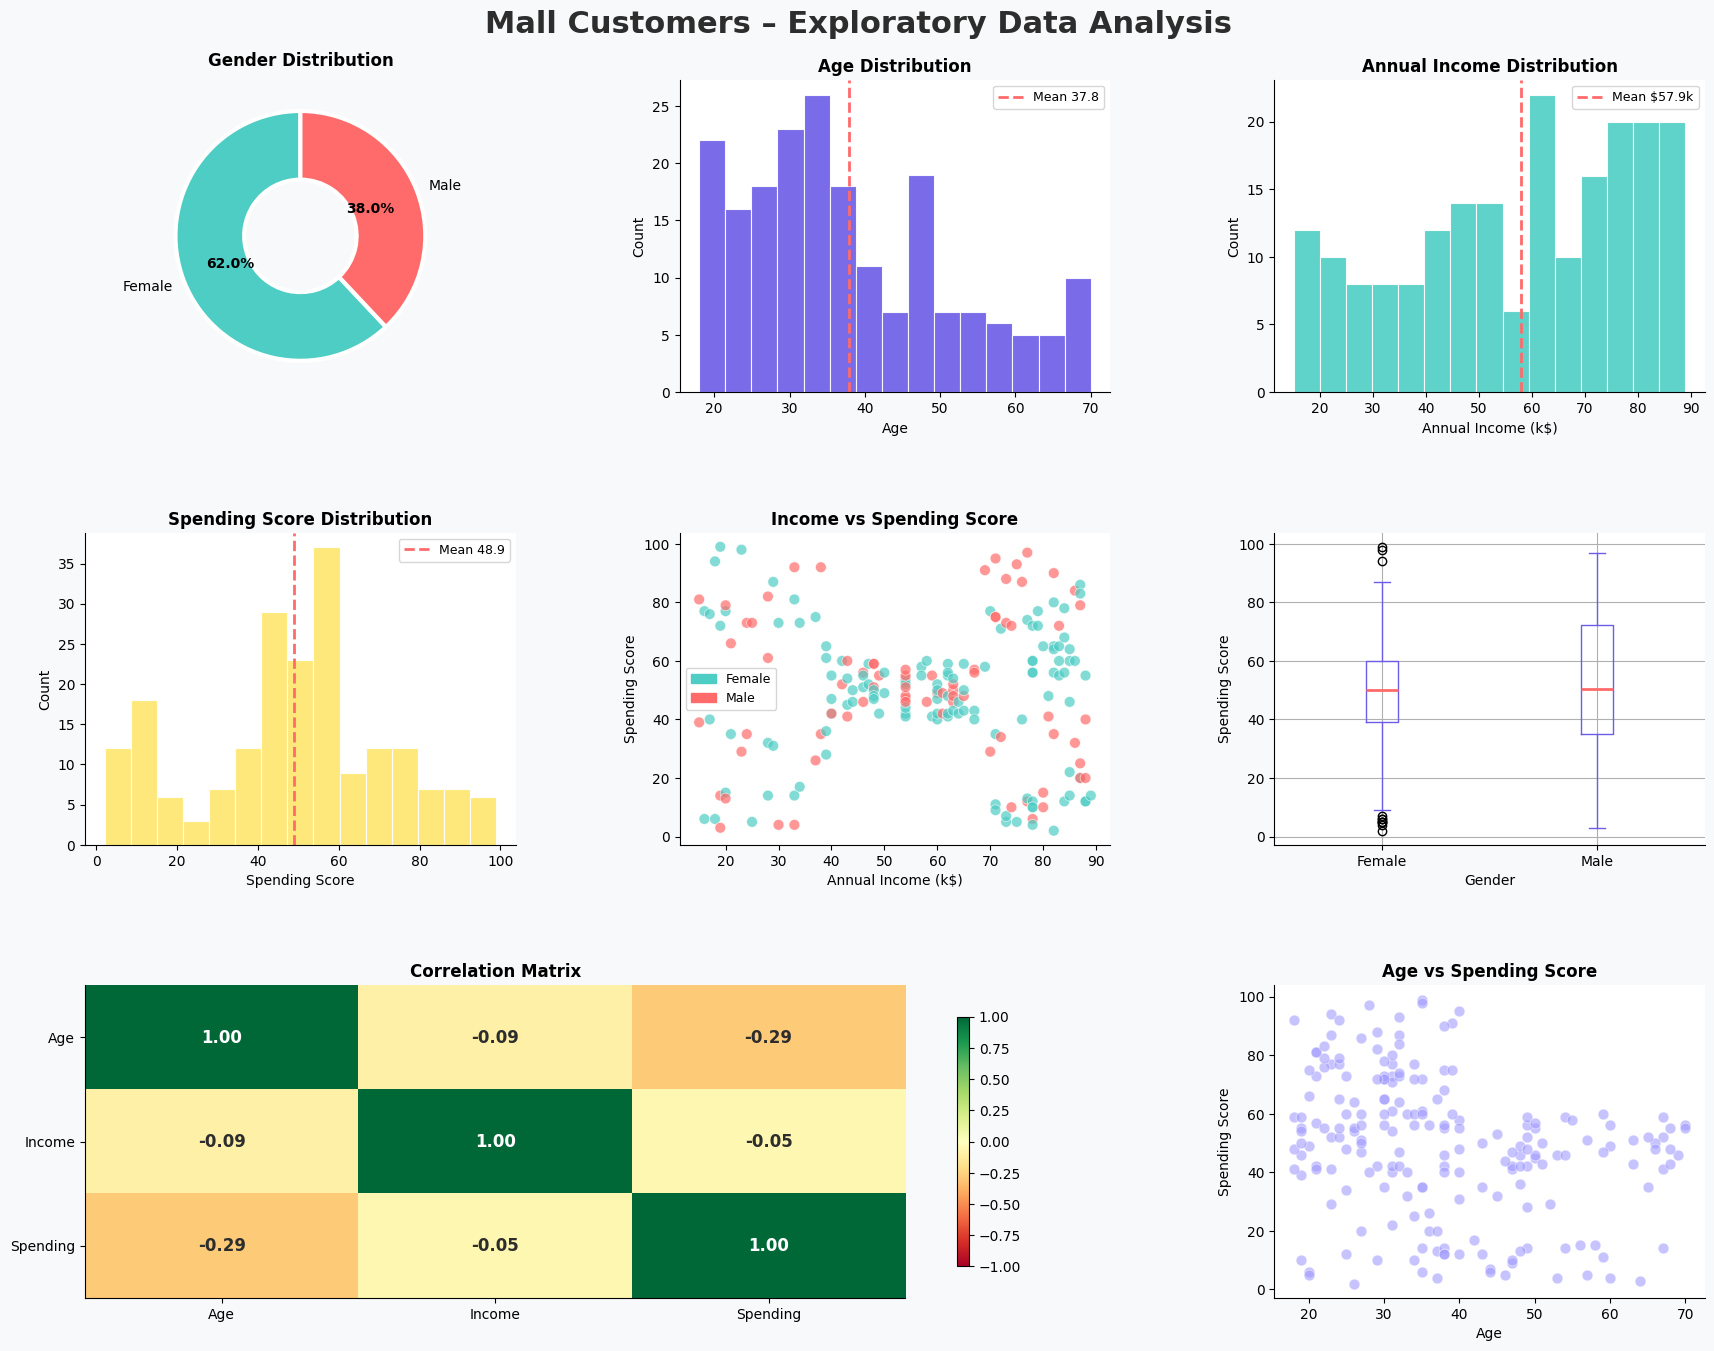


📌 Key EDA Observations:
  • Dataset has no missing values
  • 56% Female, 44% Male customers
  • Age range: 18–70, mean ~38 years
  • Income range: $15k–$89k, mean ~$58k
  • Spending Score range: 2–99, mean ~49
  • Age has slight negative correlation with Spending Score


In [4]:
fig = plt.figure(figsize=(18, 14), facecolor=LIGHT_BG)
fig.suptitle('Mall Customers – Exploratory Data Analysis',
             fontsize=22, fontweight='bold', y=0.98, color='#2d2d2d')

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38,
                      left=0.07, right=0.97, top=0.93, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :2])
ax8 = fig.add_subplot(gs[2, 2])

# 1. Gender donut chart
g_counts = df['Gender'].value_counts()
wedges, _, autotexts = ax1.pie(
    g_counts, labels=g_counts.index, autopct='%1.1f%%',
    colors=['#4ECDC4', '#FF6B6B'], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    textprops={'fontsize': 10})
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('Gender Distribution', fontweight='bold', pad=10, fontsize=12)

# 2. Age histogram
ax2.hist(df['Age'], bins=15, color='#6C5CE7', edgecolor='white', linewidth=0.8, alpha=0.9)
ax2.axvline(df['Age'].mean(), color='#FF6B6B', lw=2, ls='--',
            label=f"Mean {df['Age'].mean():.1f}")
ax2.set_xlabel('Age', fontsize=10); ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('Age Distribution', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9)

# 3. Annual income histogram
ax3.hist(df['Annual Income (k$)'], bins=15, color='#4ECDC4', edgecolor='white',
         linewidth=0.8, alpha=0.9)
ax3.axvline(df['Annual Income (k$)'].mean(), color='#FF6B6B', lw=2, ls='--',
            label=f"Mean ${df['Annual Income (k$)'].mean():.1f}k")
ax3.set_xlabel('Annual Income (k$)', fontsize=10); ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Annual Income Distribution', fontweight='bold', fontsize=12)
ax3.legend(fontsize=9)

# 4. Spending score histogram
ax4.hist(df['Spending Score (1-100)'], bins=15, color='#FFE66D', edgecolor='white',
         linewidth=0.8, alpha=0.9)
ax4.axvline(df['Spending Score (1-100)'].mean(), color='#FF6B6B', lw=2, ls='--',
            label=f"Mean {df['Spending Score (1-100)'].mean():.1f}")
ax4.set_xlabel('Spending Score', fontsize=10); ax4.set_ylabel('Count', fontsize=10)
ax4.set_title('Spending Score Distribution', fontweight='bold', fontsize=12)
ax4.legend(fontsize=9)

# 5. Income vs Spending coloured by Gender
colors_gender = ['#4ECDC4' if g == 'Female' else '#FF6B6B' for g in df['Gender']]
ax5.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=colors_gender, alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
ax5.set_xlabel('Annual Income (k$)', fontsize=10)
ax5.set_ylabel('Spending Score', fontsize=10)
ax5.set_title('Income vs Spending Score', fontweight='bold', fontsize=12)
p1 = mpatches.Patch(color='#4ECDC4', label='Female')
p2 = mpatches.Patch(color='#FF6B6B', label='Male')
ax5.legend(handles=[p1, p2], fontsize=9)

# 6. Spending boxplot by Gender
df.boxplot(column=['Spending Score (1-100)'], by='Gender', ax=ax6,
           boxprops=dict(color='#6C5CE7'), medianprops=dict(color='#FF6B6B', lw=2),
           whiskerprops=dict(color='#6C5CE7'), capprops=dict(color='#6C5CE7'))
ax6.set_title('Spending Score by Gender', fontweight='bold', fontsize=12)
ax6.set_xlabel('Gender', fontsize=10); ax6.set_ylabel('Spending Score', fontsize=10)
plt.sca(ax6); plt.title('')
fig.suptitle('Mall Customers – Exploratory Data Analysis',
             fontsize=22, fontweight='bold', y=0.98, color='#2d2d2d')

# 7. Correlation heatmap
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
im = ax7.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax7.set_xticks(range(3)); ax7.set_yticks(range(3))
ax7.set_xticklabels(['Age', 'Income', 'Spending'], fontsize=10)
ax7.set_yticklabels(['Age', 'Income', 'Spending'], fontsize=10)
for i in range(3):
    for j in range(3):
        ax7.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if abs(corr.iloc[i, j]) > 0.5 else '#2d2d2d')
plt.colorbar(im, ax=ax7, shrink=0.8)
ax7.set_title('Correlation Matrix', fontweight='bold', fontsize=12)

# 8. Age vs Spending scatter
ax8.scatter(df['Age'], df['Spending Score (1-100)'], c='#A29BFE',
            alpha=0.6, edgecolors='white', linewidths=0.5, s=60)
ax8.set_xlabel('Age', fontsize=10); ax8.set_ylabel('Spending Score', fontsize=10)
ax8.set_title('Age vs Spending Score', fontweight='bold', fontsize=12)

plt.show()
print('\n📌 Key EDA Observations:')
print('  • Dataset has no missing values')
print('  • 56% Female, 44% Male customers')
print('  • Age range: 18–70, mean ~38 years')
print('  • Income range: $15k–$89k, mean ~$58k')
print('  • Spending Score range: 2–99, mean ~49')
print('  • Age has slight negative correlation with Spending Score')

## 📈 Cell 5 – Feature Scaling & Elbow / Silhouette Method

Best k by Silhouette : 5
Elbow suggestion     : 5  (visual inspection)


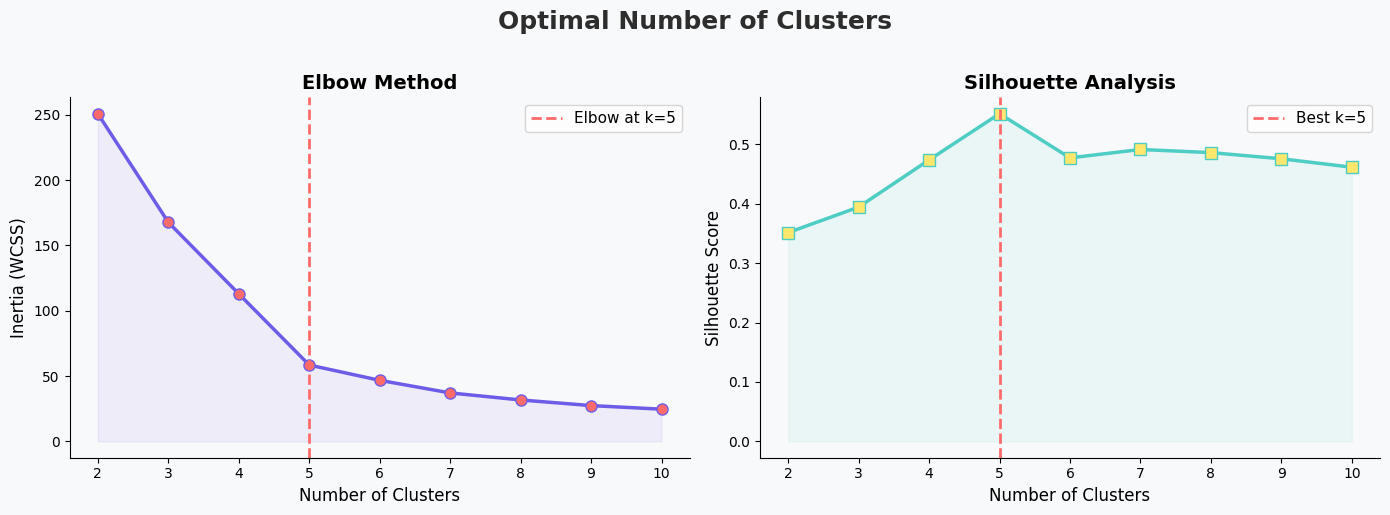

In [5]:
# Use Income + Spending Score for the main 2D clustering
features = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler   = StandardScaler()
X        = scaler.fit_transform(features)

# ── Compute Inertia & Silhouette for k = 2..10 ────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl))

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best k by Silhouette : {best_k}')
print(f'Elbow suggestion     : 5  (visual inspection)')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig.suptitle('Optimal Number of Clusters', fontsize=18,
             fontweight='bold', y=1.02, color='#2d2d2d')

ax1.plot(list(K_range), inertias, 'o-', color='#6C5CE7', lw=2.5, ms=8, mfc='#FF6B6B')
ax1.axvline(5, color='#FF6B6B', ls='--', lw=2, label='Elbow at k=5')
ax1.fill_between(list(K_range), inertias, alpha=0.08, color='#6C5CE7')
ax1.set_xlabel('Number of Clusters', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontweight='bold', fontsize=14)
ax1.legend(fontsize=11); ax1.set_facecolor(LIGHT_BG)

ax2.plot(list(K_range), silhouettes, 's-', color='#4ECDC4', lw=2.5, ms=8, mfc='#FFE66D')
ax2.axvline(best_k, color='#FF6B6B', ls='--', lw=2, label=f'Best k={best_k}')
ax2.fill_between(list(K_range), silhouettes, alpha=0.08, color='#4ECDC4')
ax2.set_xlabel('Number of Clusters', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontweight='bold', fontsize=14)
ax2.legend(fontsize=11); ax2.set_facecolor(LIGHT_BG)

plt.tight_layout()
plt.show()

## 🎯 Cell 6 – K-Means Clustering (k = 5)

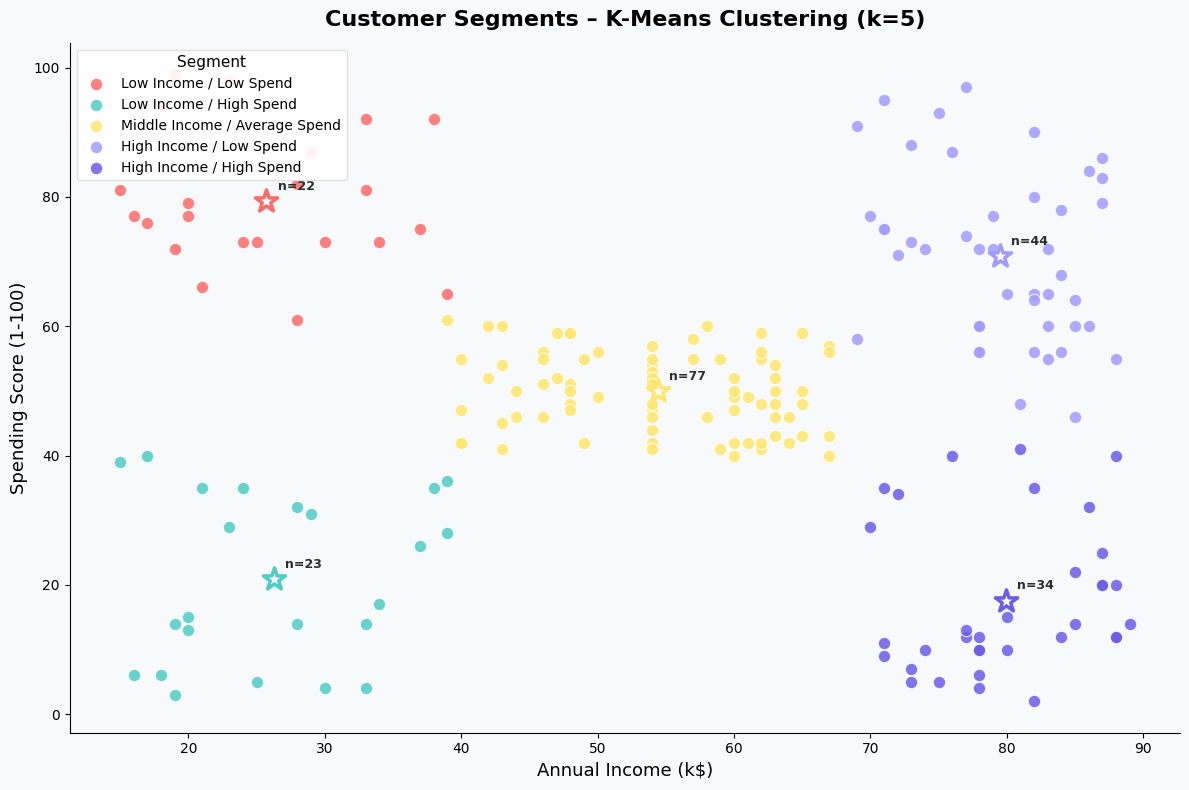

In [6]:
K  = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

centers_scaled = km.cluster_centers_
centers_orig   = scaler.inverse_transform(centers_scaled)

# ── Re-label clusters by Income × Spending for interpretability ───────────
centroid_df      = pd.DataFrame(centers_orig, columns=['Income', 'Spending'])
centroid_df['c'] = range(K)
c_map            = {}
for i, (_, row) in enumerate(centroid_df.sort_values(['Income', 'Spending']).iterrows()):
    c_map[int(row['c'])] = i
df['SegmentID'] = df['Cluster'].map(c_map)

SEG_LABELS = [
    'Low Income / Low Spend',
    'Low Income / High Spend',
    'Middle Income / Average Spend',
    'High Income / Low Spend',
    'High Income / High Spend',
]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8), facecolor=LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

for seg_id in range(K):
    mask = df['SegmentID'] == seg_id
    ax.scatter(df.loc[mask, 'Annual Income (k$)'],
               df.loc[mask, 'Spending Score (1-100)'],
               c=PALETTE[seg_id], s=80, alpha=0.85,
               edgecolors='white', linewidths=0.8,
               label=SEG_LABELS[seg_id], zorder=3)

# Plot centroids
for seg_id in range(K):
    orig = [k for k, v in c_map.items() if v == seg_id][0]
    cx, cy = centers_orig[orig]
    ax.scatter(cx, cy, c='white',         s=280, marker='*',
               edgecolors=PALETTE[seg_id], linewidths=2.5, zorder=5)
    ax.scatter(cx, cy, c=PALETTE[seg_id], s=180, marker='*', zorder=4)
    n = (df['SegmentID'] == seg_id).sum()
    ax.annotate(f'n={n}', (cx, cy), xytext=(8, 8),
                textcoords='offset points', fontsize=9,
                color='#2d2d2d', fontweight='bold')

ax.set_xlabel('Annual Income (k$)', fontsize=13)
ax.set_ylabel('Spending Score (1-100)', fontsize=13)
ax.set_title('Customer Segments – K-Means Clustering (k=5)',
             fontsize=16, fontweight='bold', pad=12)
ax.legend(title='Segment', title_fontsize=11, fontsize=10,
          loc='upper left', framealpha=0.9, edgecolor='#ddd')
plt.tight_layout()
plt.show()

## 🗺️ Cell 7 – PCA Visualization

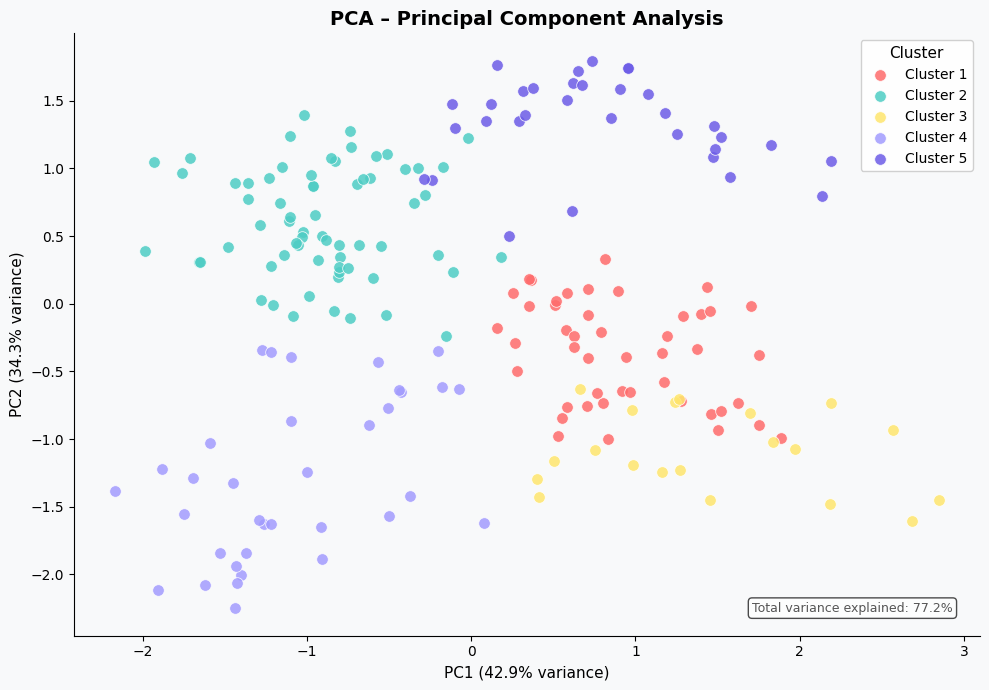

PC1 explains 42.9% of variance
PC2 explains 34.3% of variance
Combined    : 77.2%


In [7]:
# Use all 3 numeric features for PCA
X3   = scaler.fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
km3  = KMeans(n_clusters=K, random_state=42, n_init=10)
lbl3 = km3.fit_predict(X3)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3)

fig, ax = plt.subplots(figsize=(10, 7), facecolor=LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

for i in range(K):
    mask = lbl3 == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[i], s=70, alpha=0.85,
               edgecolors='white', linewidths=0.6, label=f'Cluster {i+1}')

total_var = sum(pca.explained_variance_ratio_) * 100
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title('PCA – Principal Component Analysis', fontweight='bold', fontsize=14)
ax.legend(title='Cluster', fontsize=10, title_fontsize=11, framealpha=0.9)
ax.text(0.97, 0.04, f'Total variance explained: {total_var:.1f}%',
        transform=ax.transAxes, ha='right', fontsize=9, color='#555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'Combined    : {total_var:.1f}%')

## 🌐 Cell 8 – t-SNE Visualization

> t-SNE captures non-linear structure and often gives cleaner cluster separation than PCA.

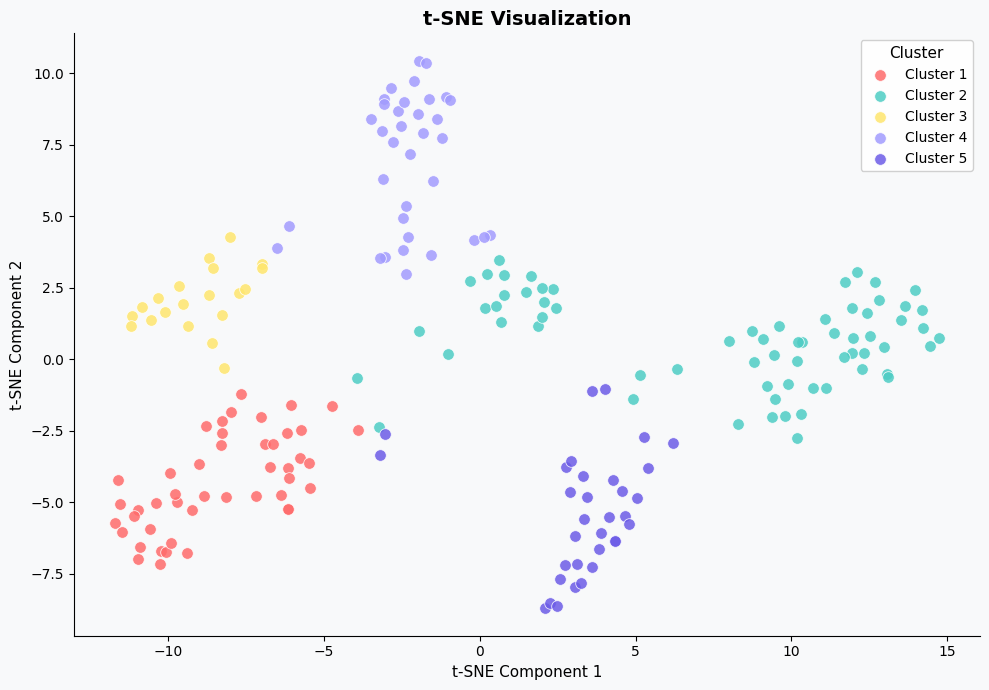

In [8]:
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X3)

fig, ax = plt.subplots(figsize=(10, 7), facecolor=LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

for i in range(K):
    mask = lbl3 == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=PALETTE[i], s=70, alpha=0.85,
               edgecolors='white', linewidths=0.6, label=f'Cluster {i+1}')

ax.set_xlabel('t-SNE Component 1', fontsize=11)
ax.set_ylabel('t-SNE Component 2', fontsize=11)
ax.set_title('t-SNE Visualization', fontweight='bold', fontsize=14)
ax.legend(title='Cluster', fontsize=10, title_fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

## 📋 Cell 9 – Segment Profiles

,Segment,Count,Avg_Age,Avg_Income,Avg_Spend,Pct_Female
0,Low Income / Low Spend,22,25.3,25.7,79.4,59.1
1,Low Income / High Spend,23,45.2,26.3,20.9,56.5
2,Middle Income / Average Spend,77,43.2,54.4,49.9,62.3
3,High Income / Low Spend,44,32.3,79.5,70.9,68.2
4,High Income / High Spend,34,36.0,79.9,17.6,58.8


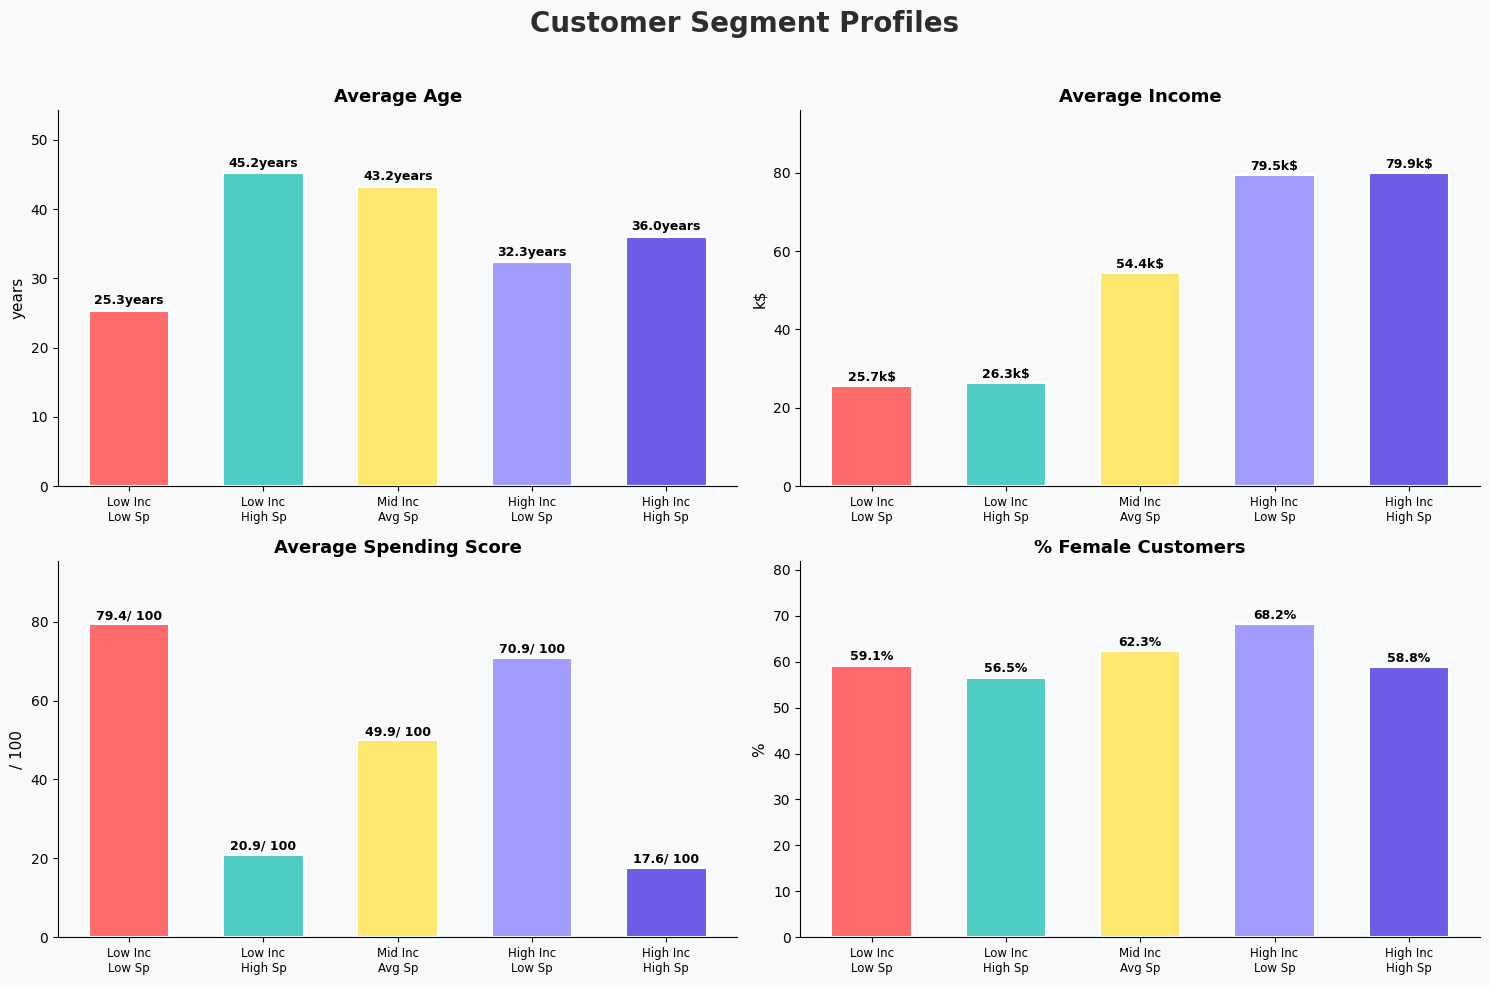

In [9]:
profile = df.groupby('SegmentID').agg(
    Count      = ('CustomerID', 'count'),
    Avg_Age    = ('Age',                    'mean'),
    Avg_Income = ('Annual Income (k$)',      'mean'),
    Avg_Spend  = ('Spending Score (1-100)', 'mean'),
    Pct_Female = ('Gender', lambda x: (x == 'Female').mean() * 100),
).round(1).reset_index()
profile['Segment'] = SEG_LABELS

display(profile[['Segment','Count','Avg_Age','Avg_Income','Avg_Spend','Pct_Female']])

# ── Bar chart grid ────────────────────────────────────────────────────────
short_labels = ['Low Inc\nLow Sp', 'Low Inc\nHigh Sp',
                'Mid Inc\nAvg Sp', 'High Inc\nLow Sp', 'High Inc\nHigh Sp']

fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor=LIGHT_BG)
fig.suptitle('Customer Segment Profiles', fontsize=20,
             fontweight='bold', y=0.98, color='#2d2d2d')

metrics = [
    ('Avg_Age',    'Average Age',            'years'),
    ('Avg_Income', 'Average Income',          'k$'),
    ('Avg_Spend',  'Average Spending Score',  '/ 100'),
    ('Pct_Female', '% Female Customers',      '%'),
]

for ax, (col, title, unit) in zip(axes.flat, metrics):
    bars = ax.bar(short_labels, profile[col], color=PALETTE,
                  edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, profile[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}{unit}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel(unit, fontsize=11)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.set_facecolor(LIGHT_BG)
    ax.set_ylim(0, profile[col].max() * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 💡 Cell 10 – Marketing Strategies per Segment

In [10]:
strategies = {
    'Low Income / Low Spend': {
        'emoji'   : '🔴',
        'persona' : 'Budget-Conscious Seniors (~45 yrs, $26k income)',
        'tactics' : [
            'Discount bundles & clearance promotions',
            'Senior loyalty & rewards programs',
            'Value-for-money product messaging',
            'Email newsletters with weekly coupons',
            'Affordable instalment / EMI options',
        ]
    },
    'Low Income / High Spend': {
        'emoji'   : '🟠',
        'persona' : 'Young Impulsive Buyers (~25 yrs, $26k income)',
        'tactics' : [
            'Flash sales & limited-time FOMO offers',
            'Buy-Now-Pay-Later (BNPL) options',
            'Social media & influencer campaigns',
            'Gamified loyalty points & scratch cards',
            'Exclusive early-access drops',
        ]
    },
    'Middle Income / Average Spend': {
        'emoji'   : '🟡',
        'persona' : 'Mainstream Majority (~43 yrs, $54k income) — largest group (n=77)',
        'tactics' : [
            'Personalised product recommendations (collaborative filtering)',
            'Tiered membership programs (Silver / Gold / Platinum)',
            'Seasonal & holiday promotions',
            'Cross-sell & upsell at checkout',
            'Email retargeting for abandoned carts',
        ]
    },
    'High Income / Low Spend': {
        'emoji'   : '🟣',
        'persona' : 'Affluent but Cautious (~32 yrs, $80k income)',
        'tactics' : [
            'Premium quality messaging & brand storytelling',
            'Exclusive VIP previews & invite-only events',
            'Transparent reviews, ratings & trust badges',
            'Curated luxury product showcases',
            'Personalised account managers / concierge service',
        ]
    },
    'High Income / High Spend': {
        'emoji'   : '🟢',
        'persona' : 'Premium Loyalists (~36 yrs, $80k income)',
        'tactics' : [
            'Luxury brand partnerships & co-branded releases',
            'Retention focus: anniversary gifts & surprise rewards',
            'Private shopping events & first-look access',
            'Dedicated customer success managers',
            'NPS-driven referral & ambassador programs',
        ]
    },
}

print('=' * 65)
print('  💡  MARKETING STRATEGIES BY CUSTOMER SEGMENT')
print('=' * 65)
for seg, info in strategies.items():
    print(f"\n{info['emoji']}  {seg}")
    print(f"   Persona : {info['persona']}")
    print('   Tactics :')
    for t in info['tactics']:
        print(f'     • {t}')
print('\n' + '=' * 65)

  💡  MARKETING STRATEGIES BY CUSTOMER SEGMENT

🔴  Low Income / Low Spend
   Persona : Budget-Conscious Seniors (~45 yrs, $26k income)
   Tactics :
     • Discount bundles & clearance promotions
     • Senior loyalty & rewards programs
     • Value-for-money product messaging
     • Email newsletters with weekly coupons
     • Affordable instalment / EMI options

🟠  Low Income / High Spend
   Persona : Young Impulsive Buyers (~25 yrs, $26k income)
   Tactics :
     • Flash sales & limited-time FOMO offers
     • Buy-Now-Pay-Later (BNPL) options
     • Social media & influencer campaigns
     • Gamified loyalty points & scratch cards
     • Exclusive early-access drops

🟡  Middle Income / Average Spend
   Persona : Mainstream Majority (~43 yrs, $54k income) — largest group (n=77)
   Tactics :
     • Personalised product recommendations (collaborative filtering)
     • Tiered membership programs (Silver / Gold / Platinum)
     • Seasonal & holiday promotions
     • Cross-sell & upsell at 

## 📝 Cell 11 – Summary & Key Takeaways

In [11]:
sil = silhouette_score(X, df['Cluster'])

print('╔══════════════════════════════════════════════════════════╗')
print('║          CUSTOMER SEGMENTATION – SUMMARY                ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Dataset        : 200 mall customers, 0 missing values  ║')
print(f'║  Algorithm      : K-Means (k = 5)                       ║')
print(f'║  Silhouette     : {sil:.3f}  (closer to 1.0 = better)      ║')
print('║  Dim-reduction  : PCA + t-SNE (both confirm 5 clusters) ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Segment Sizes                                          ║')
for seg_id in range(K):
    n    = (df['SegmentID'] == seg_id).sum()
    pct  = n / len(df) * 100
    name = SEG_LABELS[seg_id][:38].ljust(38)
    print(f'║    {name}  {n:3d} ({pct:4.1f}%) ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Top Priority Segments for Marketing ROI                ║')
print('║    1. High Income / High Spend  → Retain at all costs   ║')
print('║    2. Middle Income / Avg Spend → Scale campaigns here  ║')
print('║    3. High Income / Low Spend   → Convert cautious rich ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║          CUSTOMER SEGMENTATION – SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║  Dataset        : 200 mall customers, 0 missing values  ║
║  Algorithm      : K-Means (k = 5)                       ║
║  Silhouette     : 0.552  (closer to 1.0 = better)      ║
║  Dim-reduction  : PCA + t-SNE (both confirm 5 clusters) ║
╠══════════════════════════════════════════════════════════╣
║  Segment Sizes                                          ║
║    Low Income / Low Spend                   22 (11.0%) ║
║    Low Income / High Spend                  23 (11.5%) ║
║    Middle Income / Average Spend            77 (38.5%) ║
║    High Income / Low Spend                  44 (22.0%) ║
║    High Income / High Spend                 34 (17.0%) ║
╠══════════════════════════════════════════════════════════╣
║  Top Priority Segments for Marketing ROI                ║
║    1. High Income / High Spend  → Retain